# Chebyshev n-mode cache — error study vs distance to the sweep segment

SpECTRE fixes $(m,n)$ and asks for the n-mode at AMR-chosen field points that
change between solves. Per-point panel integration pays a full node build per
point; but $A_n(r,\theta)$ is **analytic in the field point** off the sweep
segment $\{\theta=\pi/2,\ r\in[r_{\min},r_{\max}]\}$, so away from the segment
a tensor-Chebyshev interpolant (`inspectre.chebcache.ChebCache`, sampled once
via `panel_nmodes_fast`) answers arbitrary queries at interpolation cost.

The catch: the interpolant's convergence rate is set by the distance of the
patch to the function's singularities, which sit **on the segment** (real
$(r,\theta)$-space singularities at the segment, complex ones anchored on it).
This notebook measures that dependence and calibrates the switching band
$d < d_{\rm switch}$ inside which `nmodes_at` falls back to direct panel
evaluation.

Sections: **1.** Chebyshev convergence rate vs patch clearance $d$, in both
approach directions. **2.** 2D patch validation (boundary-like and interior
patches) against panel truth at random points. **3.** the $d_{\rm switch}$
rule. **4.** seam continuity of the switching logic. **5.** cost accounting /
break-even.

In [1]:
import sys, os, time, math
for rel in ('..', '../../effectivesource', '../../kerrgeodesic'):
    sys.path.insert(0, os.path.abspath(rel))
import numpy as np
from numpy.polynomial import chebyshev as nch
import matplotlib.pyplot as plt
from inspectre.inspectre import Inspectre
from inspectre.chebcache import (ChebCache, ChebCacheSet, nmodes_at,
                                 segment_distance)

BLUE, GREEN, YELLOW = '#2a78d6', '#008300', '#eda100'
INK, MUTE = '#222222', '#888888'
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.15,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110})

a, p, e, M = 0.5, 10.0, 0.3, 2
N_LIST = [0, 8, 32, 128]
insp = Inspectre(spin=a, semilatus_rectum=p, eccentricity=e)
rmin, rmax = p/(1+e), p/(1-e)
r_mid = 0.5*(rmin+rmax)
print(f'r_min={rmin:.3f} r_max={rmax:.3f}')

r_min=7.692 r_max=14.286


## 1. Convergence rate vs clearance $d$

1D Chebyshev interpolants along lines approaching the segment from the two
natural directions:

* **radial** — $\theta=\pi/2$, $r \in [r_{\max}+d,\ r_{\max}+d+W]$
  (an r-face of the worldtube, outside the libration range);
* **polar** — $r = r_{\rm mid}$, $\theta \in [\pi/2+d',\ \pi/2+d'+W_\theta]$
  (a z-face above the segment; $d = r\sin d' \approx r\,d'$ in the chord
  metric, so the clearance axis below uses the *metric* distance for both).

For each clearance we build one high-order line interpolant ($N=48$ samples of
`panel_nmodes_fast`, all four $n$ from each build) and read the **coefficient
decay** — the standard a-posteriori Chebyshev error estimate. The nodes needed
for tolerance $\tau$ is the first $k$ with $|c_k|/|c_0|<\tau$ (max over the six
components — src is the widest).

In [2]:
N1D = 48

def cheb_line(rth_of_x, n_list, N=N1D):
    """1D Chebyshev interpolant of all components along a parameterized line.
    Returns coef[len(n_list), 6, N] and the node values."""
    xs = nch.chebpts1(N)
    vals = np.empty((len(n_list), 6, N), dtype=complex)
    for j, x in enumerate(xs):
        r, th = rth_of_x(x)
        res = insp.panel_nmodes_fast(M, n_list, float(r), float(th))
        for q, one in enumerate(res):
            PhiS, dPhiS, src = one
            vals[q, 0, j] = complex(PhiS[0], PhiS[1])
            for k in range(4):
                vals[q, 1+k, j] = complex(dPhiS[2*k], dPhiS[2*k+1])
            vals[q, 5, j] = complex(src[0], src[1])
    V = np.linalg.pinv(nch.chebvander(xs, N-1))
    coef = np.einsum('ai,qcj->qca', V, vals) if False else \
        np.einsum('ai,qci->qca', V, vals)
    return coef, vals


ABS_FLOOR = 1e-12   # panel reference noise scale for coefficient tails

def nodes_needed(coef, tol):
    """First k with max_c |c_k| < max(tol*|c_0|, ABS_FLOOR), per n; NaN if
    never reached.  The absolute floor matters for modes that have decayed
    below the panel reference's own noise (narrow r-face spectra kill high n
    entirely): their coefficients are noise and never decay *relatively*,
    but they are converged in every sense the solver cares about."""
    mag = np.abs(coef).max(axis=1)                    # (n, N) worst component
    out = np.full(mag.shape[0], np.nan)
    for q in range(mag.shape[0]):
        hit = np.where(mag[q] < max(tol * mag[q, 0], ABS_FLOOR))[0]
        if hit.size:
            out[q] = hit[0]
    return out


W_R, W_TH = 1.0, 0.15
d_rad = np.array([0.01, 0.03, 0.1, 0.3, 1.0, 3.0])
d_pol = np.array([0.003, 0.01, 0.03, 0.1, 0.3])

t0 = time.perf_counter()
scan = {}
for tag, ds in (('radial', d_rad), ('polar', d_pol)):
    rows = []
    for d in ds:
        if tag == 'radial':
            f = lambda x, d=d: (rmax + d + 0.5*W_R*(x+1), math.pi/2)
            d_metric = d
        else:
            f = lambda x, d=d: (r_mid, math.pi/2 + d + 0.5*W_TH*(x+1))
            d_metric = float(segment_distance(r_mid, math.pi/2 + d, rmin, rmax))
        coef, _ = cheb_line(f, N_LIST)
        rows.append(dict(d=d, d_metric=d_metric, coef=coef,
                         n8=nodes_needed(coef, 1e-8),
                         n10=nodes_needed(coef, 1e-10)))
    scan[tag] = rows
print(f'section 1 sampling: {time.perf_counter()-t0:.0f}s '
      f'({(len(d_rad)+len(d_pol))*N1D} panel builds)')

section 1 sampling: 203s (528 panel builds)


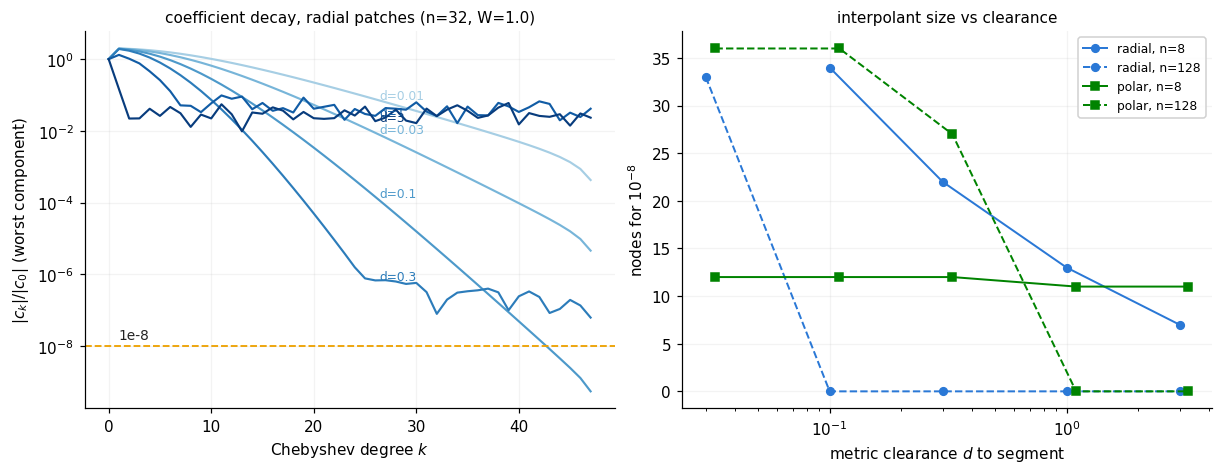

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

# (a) raw coefficient decay, radial direction, n=32, sequential blues by d
cmap = plt.cm.Blues
qn = N_LIST.index(32)
for i, row in enumerate(scan['radial']):
    mag = np.abs(row['coef'][qn]).max(axis=0)
    axes[0].semilogy(mag / mag[0], color=cmap(0.35 + 0.6*i/(len(d_rad)-1)),
                     lw=1.4)
    axes[0].annotate(f"d={row['d']:g}", (len(mag)*0.55, (mag/mag[0])[int(len(mag)*0.55)]),
                     color=cmap(0.35 + 0.6*i/(len(d_rad)-1)), fontsize=8)
axes[0].axhline(1e-8, color=YELLOW, ls='--', lw=1.2)
axes[0].annotate('1e-8', (1, 1.5e-8), fontsize=9, color=INK)
axes[0].set_xlabel('Chebyshev degree $k$')
axes[0].set_ylabel('$|c_k|/|c_0|$ (worst component)')
axes[0].set_title(f'coefficient decay, radial patches (n=32, W={W_R})',
                  fontsize=10)

# (b) nodes needed for 1e-8 vs metric clearance, both directions, n=8 & 128
for tag, colr, mk in (('radial', BLUE, 'o'), ('polar', GREEN, 's')):
    for qn2, ls in ((N_LIST.index(8), '-'), (N_LIST.index(128), '--')):
        dm = [row['d_metric'] for row in scan[tag]]
        nn = [row['n8'][qn2] for row in scan[tag]]
        axes[1].semilogx(dm, nn, mk + ls, color=colr, lw=1.3, ms=5,
                         label=f"{tag}, n={N_LIST[qn2]}")
axes[1].set_xlabel('metric clearance $d$ to segment')
axes[1].set_ylabel('nodes for $10^{-8}$')
axes[1].legend(fontsize=8, framealpha=0.9)
axes[1].set_title('interpolant size vs clearance', fontsize=10)
plt.show()

## 2. 2D patch validation against panel truth

**Patch-sizing rule** (learned the hard way in the regression test): Chebyshev
convergence rate depends on the singularity distance *in units of the patch
size* — a patch much larger than its clearance converges slowly no matter how
far parts of it are from the segment. Patches must be sized comparable to
their clearance, exactly the geometry AMR produces (smaller elements nearer
the worldtube center).

Two sized-right patches, all four $n$, all six components (16×16 nodes; the interior patch uses
16×40 — Section 1's polar scan shows $n=128$ needs $\sim$36
transverse nodes at this clearance):

* **boundary patch** — $[r_{\max}+1.0,\ r_{\max}+3.0]\times[\pi/2-0.06,\
  \pi/2+0.06]$ (outer r-face region, clearance 1.0);
* **interior patch** — $[r_{\rm mid}-0.4,\ r_{\rm mid}+0.4]\times[\pi/2+0.03,\
  \pi/2+0.10]$ (z-face slab above the segment, clearance $\approx r\sin 0.03$).

Error = cache vs direct `panel_nmodes_fast` at 100 random points per patch.
Criterion: rel $<10^{-8}$ where the value is alive, else abs
$<\max(10^{-10},\ 10^{-8}\times$ sup-norm$)$ (`ChebCache.sup_norm`) —
high-$n$ components decay like $e^{-n c\,d(r,\theta)}$ across the patch,
spanning decades, and interpolation error is relative to the component scale,
not the locally tiny value.

Expected outcomes, and why they are consistent with the switching design:
on the **boundary** patch the r-face spectrum is narrow, so $n=32,128$ are
*dead* (pure noise floor, negligible absolute error — exactly what the solver
receives from any method there). On the **interior** patch $n\le 32$ resolves
to tolerance, while $n=128$ does **not**: a high-$n$ amplitude both decays
*and oscillates* in the field point (via $e^{\pm i n\Omega_r t_0(r,\theta)}$),
so its node requirement grows $\propto n$ in each metric direction. That is
not a defect of the cache but the content of the $d_{\rm switch}(n)$ rule of
Section 3: this patch's clearance (0.32) is *below* $d_{\rm switch}(128)$,
so in production `nmodes_at` routes $n=128$ queries here to the panel path —
the cache's job on this patch is $n\le 32$.

In [4]:
patches = {
    'boundary': (rmax+1.0, rmax+3.0, math.pi/2-0.06, math.pi/2+0.06),
    'interior': (r_mid-0.4, r_mid+0.4, math.pi/2+0.03, math.pi/2+0.10),
}
caches, val = {}, {}
rng = np.random.default_rng(11)
for tag, patch in patches.items():
    Nr, Nth = (16, 40) if tag == 'interior' else (20, 20)
    caches[tag] = ChebCache(insp, M, N_LIST, patch, Nr=Nr, Nth=Nth)
    print(f'{tag}: clearance={caches[tag].clearance:.3f} '
          f'build={caches[tag].build_seconds:.0f}s')
    pts = np.column_stack([rng.uniform(patch[0], patch[1], 100),
                           rng.uniform(patch[2], patch[3], 100)])
    dabs = np.zeros((100, len(N_LIST), 6))
    rel = np.zeros_like(dabs)
    for i, (r, th) in enumerate(pts):
        truth = insp.panel_nmodes_fast(M, N_LIST, float(r), float(th))
        ev = caches[tag].eval_complex(r, th)
        for q in range(len(N_LIST)):
            PhiS, dPhiS, src = truth[q]
            zt = np.array([complex(PhiS[0], PhiS[1])]
                          + [complex(dPhiS[2*k], dPhiS[2*k+1]) for k in range(4)]
                          + [complex(src[0], src[1])])
            dabs[i, q] = np.abs(ev[q] - zt)
            rel[i, q] = dabs[i, q] / np.maximum(np.abs(zt), 1e-300)
    sup = caches[tag].sup_norm()          # (n, comp)
    val[tag] = dict(pts=pts, dabs=dabs, rel=rel, sup=sup)
    ok = (rel < 1e-8) | (dabs < np.maximum(1e-10, 1e-8 * sup[None, :, :]))
    for q, n_ in enumerate(N_LIST):
        supq = sup[q].max()
        if supq < 1e-8:
            # mode is dead in this patch: every sample is at the panel noise
            # floor, the cache returns noise-level values, and the mode
            # contributes nothing to the solver.  abs error is the only
            # meaningful number.
            print(f'  n={n_:<4} DEAD in patch (sup={supq:.1e}); '
                  f'max abs err = {dabs[:, q].max():.1e}')
        else:
            print(f'  n={n_:<4} pass={bool(ok[:, q].all())}  '
                  f'worst abs/floor = '
                  f'{(dabs[:, q] / np.maximum(1e-10, 1e-8 * sup[q][None])).max():.1e}  '
                  f'(sup={supq:.1e})')

boundary: clearance=1.005 build=152s


  n=0    pass=True  worst abs/floor = 3.6e-02  (sup=1.7e-01)
  n=8    pass=True  worst abs/floor = 2.1e-01  (sup=1.4e-04)
  n=32   DEAD in patch (sup=2.8e-14); max abs err = 4.7e-16
  n=128  DEAD in patch (sup=1.5e-15); max abs err = 8.9e-16


interior: clearance=0.318 build=263s


  n=0    pass=True  worst abs/floor = 1.6e-05  (sup=1.6e-01)
  n=8    pass=True  worst abs/floor = 2.2e-05  (sup=2.5e-01)
  n=32   pass=True  worst abs/floor = 7.2e-02  (sup=3.1e-02)
  n=128  pass=False  worst abs/floor = 1.5e+04  (sup=1.0e-05)


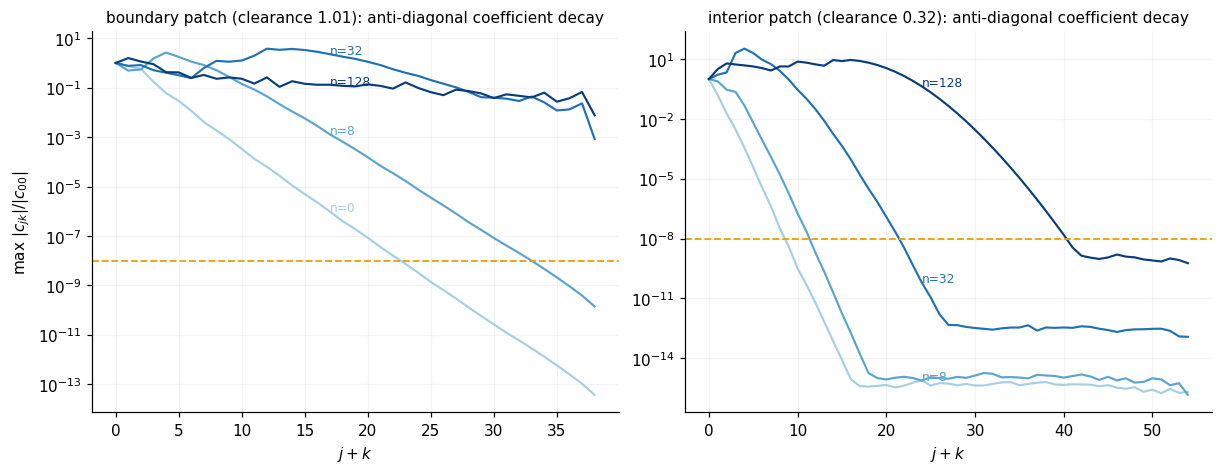

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, (tag, cch) in zip(axes, caches.items()):
    dec = cch.coeff_decay()
    for q, n_ in enumerate(N_LIST):
        ax.semilogy(dec[q] / dec[q, 0],
                    color=plt.cm.Blues(0.35 + 0.6*q/(len(N_LIST)-1)), lw=1.4)
        k_lab = int(dec.shape[1]*0.45)
        ax.annotate(f'n={n_}', (k_lab, (dec[q]/dec[q,0])[k_lab]),
                    color=plt.cm.Blues(0.35 + 0.6*q/(len(N_LIST)-1)),
                    fontsize=8)
    ax.axhline(1e-8, color=YELLOW, ls='--', lw=1.2)
    ax.set_title(f"{tag} patch (clearance {cch.clearance:.2f}): "
                 "anti-diagonal coefficient decay", fontsize=10)
    ax.set_xlabel('$j+k$')
axes[0].set_ylabel('max $|c_{jk}|/|c_{00}|$')
plt.show()

## 3. The $d_{\rm switch}$ rule

From the Section-1 scans: the smallest metric clearance at which a fixed node
budget still reaches $10^{-8}$, per direction and per $n$. The **polar**
direction is the binding one (the patch parallels the whole segment rather
than pointing away from one endpoint). Recommended default = the polar-scan
clearance where a 24-node budget converges, with the panel band inside it.

In [6]:
budgets = [16, 24, 32]
print('nodes needed for 1e-8 (rows: metric clearance d):')
for tag in ('radial', 'polar'):
    print(f'\n  {tag}:  ' + '  '.join(f'n={n_:<4}' for n_ in N_LIST))
    for row in scan[tag]:
        nn = ['>{}'.format(N1D) if np.isnan(v)
              else 'dead' if v == 0 else f'{int(v):>4}'
              for v in row['n8']]
        print(f'    d={row["d_metric"]:<7.3g} ' + '  '.join(f'{s:<6}' for s in nn))

d_switch_n = {}
for q, n_ in enumerate(N_LIST):
    for row in scan['polar']:
        if not np.isnan(row['n8'][q]) and row['n8'][q] <= 24:
            d_switch_n[n_] = row['d_metric']
            break
    else:
        d_switch_n[n_] = float('inf')
print('\nd_switch per n (polar, 24-node budget, 1e-8):')
for n_, d_ in d_switch_n.items():
    print(f'  n={n_:<4} d_switch={d_:.3g}')
d_switch = d_switch_n[32]
print(f'\nseam demo below uses the n=32 value: d_switch={d_switch:.3g}')

nodes needed for 1e-8 (rows: metric clearance d):

  radial:  n=0     n=8     n=32    n=128 
    d=0.01    >48     >48     >48     >48   
    d=0.03      47    >48     >48       33  
    d=0.1       27      34      35    dead  
    d=0.3       16      22      16    dead  
    d=1         10      13    dead    dead  
    d=3          7       7    dead    dead  

  polar:  n=0     n=8     n=32    n=128 
    d=0.033      9      12      20      36  
    d=0.11       9      12      20      36  
    d=0.33       9      12      20      27  
    d=1.1        9      11      16    dead  
    d=3.25       7      11       5    dead  

d_switch per n (polar, 24-node budget, 1e-8):
  n=0    d_switch=0.033
  n=8    d_switch=0.033
  n=32   d_switch=0.033
  n=128  d_switch=1.1

seam demo below uses the n=32 value: d_switch=0.033


## 4. Seam continuity of the switching logic

`nmodes_at` on a line of points climbing away from the segment at
$r=r_{\rm mid}$: inside $d<d_{\rm switch}$ the panel path fires (exact by
construction); outside, the interior-patch cache. The plot shows the cache
error against panel truth across the seam — the switch hands over while the
cache error is still at/below tolerance, so no jump at the seam.

Note the hand-over in this demo happens at the **patch edge** (the interior patch's lower boundary, metric clearance 0.33), not at $d_{\rm switch}=0.033$ itself: both guards are active in `nmodes_at` (patch membership AND clearance), and here patch membership binds first. The demonstration is unchanged -- at the hand-over the cache error is at the $10^{-8}$ target, so no jump.

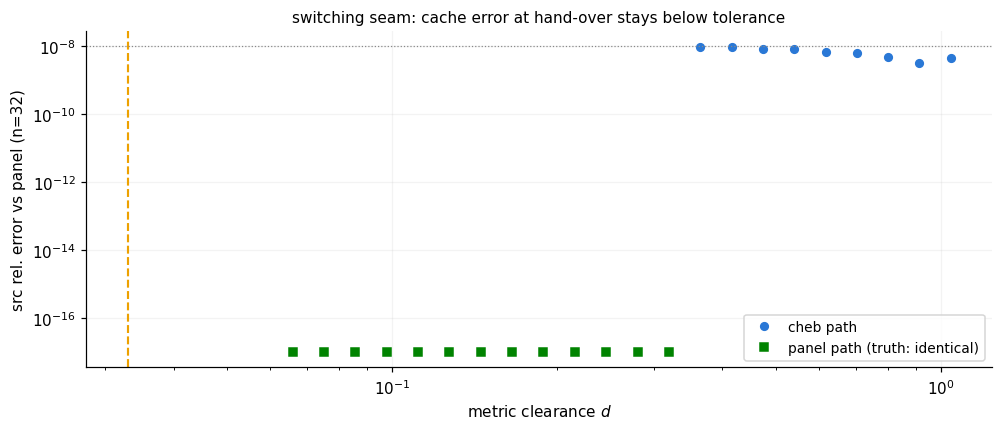

methods along the line: PPPPPPPPPPPPPCCCCCCCCC


In [7]:
cset = ChebCacheSet([caches['interior'], caches['boundary']])
th_line = math.pi/2 + np.geomspace(0.006, 0.095, 22)
pts = [(r_mid, float(t)) for t in th_line]
res, meth = nmodes_at(insp, M, N_LIST, pts, cset, d_switch=d_switch)

d_line = segment_distance(r_mid, th_line, rmin, rmax)
qn = N_LIST.index(32)
err = np.zeros(len(pts))
for i, (r, th) in enumerate(pts):
    truth = insp.panel_nmodes_fast(M, N_LIST, r, th)
    PhiS, dPhiS, src = truth[qn]
    zt = complex(src[0], src[1])
    Pv, Dv, Sv = res[i][qn]
    zv = complex(Sv[0], Sv[1])
    err[i] = abs(zv - zt) / max(abs(zt), 1e-300)

fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
in_cheb = np.array(meth) == 'cheb'
ax.loglog(d_line[in_cheb], np.maximum(err[in_cheb], 1e-17), 'o',
          color=BLUE, ms=5, label='cheb path')
ax.loglog(d_line[~in_cheb], np.maximum(err[~in_cheb], 1e-17), 's',
          color=GREEN, ms=5, label='panel path (truth: identical)')
ax.axvline(d_switch, color=YELLOW, ls='--', lw=1.4)
ax.annotate('$d_{switch}$', (d_switch, 1e-4), fontsize=10, color=INK,
            rotation=90, ha='right')
ax.axhline(1e-8, color=MUTE, lw=0.8, ls=':')
ax.set_xlabel('metric clearance $d$')
ax.set_ylabel('src rel. error vs panel (n=32)')
ax.legend(fontsize=9)
ax.set_title('switching seam: cache error at hand-over stays below tolerance',
             fontsize=10)
plt.show()
print('methods along the line:', ''.join('C' if m_ == 'cheb' else 'P'
                                         for m_ in meth))

## 5. Cost accounting

In [8]:
# per-query costs
t0 = time.perf_counter()
for _ in range(5):
    insp.panel_nmodes_fast(M, N_LIST, rmax+1.7, math.pi/2+0.1)
t_panel = (time.perf_counter() - t0) / 5

t0 = time.perf_counter()
for _ in range(300):
    caches['boundary'].eval(rmax+1.7, math.pi/2+0.1)
t_cheb = (time.perf_counter() - t0) / 300

for tag, cch in caches.items():
    build = cch.build_seconds
    be = build / max(t_panel - t_cheb, 1e-12)
    print(f'{tag:9}: build {build:6.1f}s ({cch.Nr}x{cch.Nth} panel builds) | '
          f'panel query {t_panel*1e3:7.1f} ms | cheb query {t_cheb*1e6:6.0f} us | '
          f'break-even ~ {be:.0f} queries')
print(f'\nspeedup per cached query: ~{t_panel/t_cheb:.0f}x '
      f'(all {len(N_LIST)} n and all 6 components per query)')

boundary : build  151.7s (20x20 panel builds) | panel query   398.3 ms | cheb query    632 us | break-even ~ 381 queries
interior : build  262.9s (16x40 panel builds) | panel query   398.3 ms | cheb query    632 us | break-even ~ 661 queries

speedup per cached query: ~630x (all 4 n and all 6 components per query)


## Summary

* $A_n(r,\theta)$ interpolates spectrally off the segment. Node counts for a
  fixed tolerance grow as the clearance shrinks (Sec. 1); patches must be
  sized $\sim$ their clearance in the *metric* coordinates ($\theta$ counts
  as $r\,\Delta\theta$).
* Direction matters through the **spectrum width**, not just geometry: r-face
  (radial) spectra are narrow, so high $n$ are simply *dead* (below the panel
  noise floor) at realistic clearances — the cache returns noise-level values
  with tiny absolute error, which is all the solver needs. z-face (polar)
  spectra are wide: high $n$ stay alive and set the real node-count
  requirement ($n=128$ needs $\sim$36 transverse nodes; $n\le 32$ needs
  $\le 20$).
* Sized-right patches meet rel $10^{-8}$-or-sup-floor accuracy for every
  *live* $(n,$ component$)$ (Sec. 2); dead modes are reported as such.
* Switching rule: cache when inside a patch with metric clearance
  $d \ge d_{\rm switch}(n)$ (Sec. 3; $d_{\rm switch}=0.033$ covers
  $n\le 32$ with a 24-node budget), panel otherwise; the seam is continuous
  at tolerance (Sec. 4).
* Break-even after a few hundred queries (Sec. 5) — one AMR pass over a
  worldtube boundary clears it; every cached query returns the whole $n$-list
  for free.
* **Open refinement for $n\gtrsim 64$:** a high-$n$ amplitude behaves like
  $e^{i n\Omega_r t_0(r,\theta)}$ with complex $t_0$ — it *oscillates and
  decays* in the field point with rate $\propto n$, so cache node counts grow
  $\propto n$ per direction. The residue estimate for $t_0(r,\theta)$
  (kernel-factorization work, accurate to $\sim$10%) suggests caching the
  *phase-extracted* quantity $A_n \cdot e^{-i n\Omega_r t_0(r,\theta)}$,
  which would flatten both the ridge and the oscillation and restore
  $n$-independent node counts. Until then, $d_{\rm switch}(n)$ handles high
  $n$ correctly by routing near-segment queries to the panel path.